In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats as st

In [2]:
games_data = pd.read_csv("/datasets/games.csv")

games_data.info()
games_data.head() #visualizamos la informacion y las primeras lineas del dataset

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             16713 non-null  object 
 1   Platform         16715 non-null  object 
 2   Year_of_Release  16446 non-null  float64
 3   Genre            16713 non-null  object 
 4   NA_sales         16715 non-null  float64
 5   EU_sales         16715 non-null  float64
 6   JP_sales         16715 non-null  float64
 7   Other_sales      16715 non-null  float64
 8   Critic_Score     8137 non-null   float64
 9   User_Score       10014 non-null  object 
 10  Rating           9949 non-null   object 
dtypes: float64(6), object(5)
memory usage: 1.4+ MB


,Name,Platform,Year_of_Release,Genre,NA_sales,EU_sales,JP_sales,Other_sales,Critic_Score,User_Score,Rating
0,Wii Sports,Wii,2006.0,Sports,41.36,28.96,3.77,8.45,76.0,8,E
1,Super Mario Bros.,NES,1985.0,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008.0,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E
3,Wii Sports Resort,Wii,2009.0,Sports,15.61,10.93,3.28,2.95,80.0,8,E
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN


In [3]:
#Preparacion de datos

games_data.columns = games_data.columns.str.lower() #columnas en minusculas

games_data.info() #verificamos

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             16713 non-null  object 
 1   platform         16715 non-null  object 
 2   year_of_release  16446 non-null  float64
 3   genre            16713 non-null  object 
 4   na_sales         16715 non-null  float64
 5   eu_sales         16715 non-null  float64
 6   jp_sales         16715 non-null  float64
 7   other_sales      16715 non-null  float64
 8   critic_score     8137 non-null   float64
 9   user_score       10014 non-null  object 
 10  rating           9949 non-null   object 
dtypes: float64(6), object(5)
memory usage: 1.4+ MB


In [4]:
games_data.isna().sum() #verificamos valores ausentes

name                  2
platform              0
year_of_release     269
genre                 2
na_sales              0
eu_sales              0
jp_sales              0
other_sales           0
critic_score       8578
user_score         6701
rating             6766
dtype: int64

In [5]:
games_data[games_data["name"].isna()] #verificamos datos ausentes en name

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
659,NaN,GEN,1993.0,NaN,1.78,0.53,0.00,0.08,NaN,NaN,NaN
14244,NaN,GEN,1993.0,NaN,0.00,0.00,0.03,0.00,NaN,NaN,NaN


In [6]:
#podemos observar que los valores en name y genre son NaN coincidiendo con la verificacion anterior de valores ausentes
#admeas obervamos que ambos juegos son de 1993 lo cual estan alejados del año de analisis 2017, por tanto estas quedarian
#fuera de rango, se eliminan

In [7]:
games_data = games_data.dropna(subset = ["genre"]).reset_index(drop = True) #Se eliminan datos ausentes de genre y reseteamos el index

In [8]:
games_data["genre"].isna().sum() #verificamos

0

In [9]:
games_data[games_data["year_of_release"].isna()] #datos ausentes en year_of_release

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
183,Madden NFL 2004,PS2,NaN,Sports,4.26,0.26,0.01,0.71,94.0,8.5,E
377,FIFA Soccer 2004,PS2,NaN,Sports,0.59,2.36,0.04,0.51,84.0,6.4,E
456,LEGO Batman: The Videogame,Wii,NaN,Action,1.80,0.97,0.00,0.29,74.0,7.9,E10+
475,wwe Smackdown vs. Raw 2006,PS2,NaN,Fighting,1.57,1.02,0.00,0.41,NaN,NaN,NaN
609,Space Invaders,2600,NaN,Shooter,2.36,0.14,0.00,0.03,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
16371,PDC World Championship Darts 2008,PSP,NaN,Sports,0.01,0.00,0.00,0.00,43.0,tbd,E10+
16403,Freaky Flyers,GC,NaN,Racing,0.01,0.00,0.00,0.00,69.0,6.5,T
16446,Inversion,PC,NaN,Shooter,0.01,0.00,0.00,0.00,59.0,6.7,M
16456,Hakuouki: Shinsengumi Kitan,PS3,NaN,Adventure,0.01,0.00,0.00,0.00,NaN,NaN,NaN


In [10]:
#encontramos 269 valores ausentes en year_of_release se observa de diferentes plataformas y es dificil determinar el año de
#publicacion basandonos en las ventas, hay veces que algunos juegos se publican en unas regiones antes que otras
#ya que la cantidad es pequeña comparado con el tamaño del dataset, eliminaremos estos valores

In [11]:
games_data = games_data.dropna(subset = ["year_of_release"]).reset_index(drop = True) #eliminamos valores NaN y reseteamos el index

In [12]:
games_data["year_of_release"].isnull().sum() #verificamos

0

In [13]:
games_data[games_data["rating"].isna()] #datos ausentes en rating

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
1,Super Mario Bros.,NES,1985.0,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN
5,Tetris,GB,1989.0,Puzzle,23.20,2.26,4.22,0.58,NaN,NaN,NaN
9,Duck Hunt,NES,1984.0,Shooter,26.93,0.63,0.28,0.47,NaN,NaN,NaN
10,Nintendogs,DS,2005.0,Simulation,9.05,10.95,1.93,2.74,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
16439,Samurai Warriors: Sanada Maru,PS3,2016.0,Action,0.00,0.00,0.01,0.00,NaN,NaN,NaN
16440,LMA Manager 2007,X360,2006.0,Sports,0.00,0.01,0.00,0.00,NaN,NaN,NaN
16441,Haitaka no Psychedelica,PSV,2016.0,Adventure,0.00,0.00,0.01,0.00,NaN,NaN,NaN
16442,Spirits & Spells,GBA,2003.0,Platform,0.01,0.00,0.00,0.00,NaN,NaN,NaN


In [14]:
games_data["rating"].unique() #datos unicos para ESRB, clasificacion de juegos contenido - edad

array(['E', nan, 'M', 'T', 'E10+', 'K-A', 'AO', 'EC', 'RP'], dtype=object)

In [15]:
#ya que los juegos que tienen valores NaN no tienen datos de clasificacion, y nosotros no podemos evaluar el contenido y 
#asignarle una clasificacion, a estos valores ausentes los rellenamos con el termino unknown

games_data["rating"] = games_data["rating"].fillna(value = "unknown")

In [16]:
games_data["rating"].isnull().sum() #verificamos

0

In [17]:
games_data[games_data["user_score"].isna()] #datos ausentes en user_score

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
1,Super Mario Bros.,NES,1985.0,Platform,29.08,3.58,6.81,0.77,NaN,NaN,unknown
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,unknown
5,Tetris,GB,1989.0,Puzzle,23.20,2.26,4.22,0.58,NaN,NaN,unknown
9,Duck Hunt,NES,1984.0,Shooter,26.93,0.63,0.28,0.47,NaN,NaN,unknown
10,Nintendogs,DS,2005.0,Simulation,9.05,10.95,1.93,2.74,NaN,NaN,unknown
...,...,...,...,...,...,...,...,...,...,...,...
16439,Samurai Warriors: Sanada Maru,PS3,2016.0,Action,0.00,0.00,0.01,0.00,NaN,NaN,unknown
16440,LMA Manager 2007,X360,2006.0,Sports,0.00,0.01,0.00,0.00,NaN,NaN,unknown
16441,Haitaka no Psychedelica,PSV,2016.0,Adventure,0.00,0.00,0.01,0.00,NaN,NaN,unknown
16442,Spirits & Spells,GBA,2003.0,Platform,0.01,0.00,0.00,0.00,NaN,NaN,unknown


In [18]:
games_data[games_data["critic_score"].isna()] #datos ausentes en critic_score

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
1,Super Mario Bros.,NES,1985.0,Platform,29.08,3.58,6.81,0.77,NaN,NaN,unknown
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,unknown
5,Tetris,GB,1989.0,Puzzle,23.20,2.26,4.22,0.58,NaN,NaN,unknown
9,Duck Hunt,NES,1984.0,Shooter,26.93,0.63,0.28,0.47,NaN,NaN,unknown
10,Nintendogs,DS,2005.0,Simulation,9.05,10.95,1.93,2.74,NaN,NaN,unknown
...,...,...,...,...,...,...,...,...,...,...,...
16439,Samurai Warriors: Sanada Maru,PS3,2016.0,Action,0.00,0.00,0.01,0.00,NaN,NaN,unknown
16440,LMA Manager 2007,X360,2006.0,Sports,0.00,0.01,0.00,0.00,NaN,NaN,unknown
16441,Haitaka no Psychedelica,PSV,2016.0,Adventure,0.00,0.00,0.01,0.00,NaN,NaN,unknown
16442,Spirits & Spells,GBA,2003.0,Platform,0.01,0.00,0.00,0.00,NaN,NaN,unknown


In [19]:
#usualmente las puntuaciones de criticos y usuarios estan relacionados entre si, en la mayoria de los casos son similares y
#no tenemos forma de rellenar este dato, por lo tanto los dejaremos de esta manera, tambien podemos observar que en user_score
#hay valores bajo el concepto "tbd"

In [20]:
games_data[games_data["user_score"] == "tbd"] #datos con tbd

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
119,Zumba Fitness,Wii,2010.0,Sports,3.45,2.59,0.0,0.66,NaN,tbd,E
300,Namco Museum: 50th Anniversary,PS2,2005.0,Misc,2.08,1.35,0.0,0.54,61.0,tbd,E10+
516,Zumba Fitness 2,Wii,2011.0,Sports,1.51,1.03,0.0,0.27,NaN,tbd,T
639,uDraw Studio,Wii,2010.0,Misc,1.65,0.57,0.0,0.20,71.0,tbd,E
709,Just Dance Kids,Wii,2010.0,Misc,1.52,0.54,0.0,0.18,NaN,tbd,E
...,...,...,...,...,...,...,...,...,...,...,...
16424,Planet Monsters,GBA,2001.0,Action,0.01,0.00,0.0,0.00,67.0,tbd,E
16426,Bust-A-Move 3000,GC,2003.0,Puzzle,0.01,0.00,0.0,0.00,53.0,tbd,E
16427,Mega Brain Boost,DS,2008.0,Puzzle,0.01,0.00,0.0,0.00,48.0,tbd,E
16433,Plushees,DS,2008.0,Simulation,0.01,0.00,0.0,0.00,NaN,tbd,E


In [21]:
#tbd tampoco les podemos asignar un valor ya que el usuario es quien omitio asignar el valor, por tanto los transformaremos
#a valores nulos para evitar problemas

In [22]:
games_data.loc[games_data["user_score"] == "tbd", "user_score"] = np.nan #transformamos tbd to nan

In [23]:
games_data[games_data["user_score"] == "tbd"] #verificamos

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating


In [24]:
#Creamos la columna de ventas globales sumando los valores de venta de cada region (incluyendo otros)

In [25]:
games_data["global_sales"] = games_data["na_sales"] + games_data["eu_sales"] + games_data["jp_sales"] + games_data["other_sales"]

In [26]:
games_data.head() #verificamos

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,global_sales
0,Wii Sports,Wii,2006.0,Sports,41.36,28.96,3.77,8.45,76.0,8,E,82.54
1,Super Mario Bros.,NES,1985.0,Platform,29.08,3.58,6.81,0.77,NaN,NaN,unknown,40.24
2,Mario Kart Wii,Wii,2008.0,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E,35.52
3,Wii Sports Resort,Wii,2009.0,Sports,15.61,10.93,3.28,2.95,80.0,8,E,32.77
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,unknown,31.38


In [27]:
#Hemos procesado los datos para el analisis, ahora solo verificamos que todas las columnas tengan el tipo de dato correcto
#para ello volvemos a utilizar .info() para checar el df

In [28]:
games_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16444 entries, 0 to 16443
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             16444 non-null  object 
 1   platform         16444 non-null  object 
 2   year_of_release  16444 non-null  float64
 3   genre            16444 non-null  object 
 4   na_sales         16444 non-null  float64
 5   eu_sales         16444 non-null  float64
 6   jp_sales         16444 non-null  float64
 7   other_sales      16444 non-null  float64
 8   critic_score     7983 non-null   float64
 9   user_score       7463 non-null   object 
 10  rating           16444 non-null  object 
 11  global_sales     16444 non-null  float64
dtypes: float64(7), object(5)
memory usage: 1.5+ MB


In [29]:
#notamos que year_of_release es tipo float64 cuando deberia ser int y user_score es tipo object cuando deberia ser float64 al
#igual que critic_score, por tanto tenemos que hacer el cambio de tipo de dato al correspondiente

In [30]:
games_data["year_of_release"] = games_data["year_of_release"].astype(int) #convertimos year_of_release a int

In [31]:
games_data["user_score"] = games_data["user_score"].astype(float) #convertimos user_score a float64

In [32]:
games_data.info() #verificamos

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16444 entries, 0 to 16443
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             16444 non-null  object 
 1   platform         16444 non-null  object 
 2   year_of_release  16444 non-null  int64  
 3   genre            16444 non-null  object 
 4   na_sales         16444 non-null  float64
 5   eu_sales         16444 non-null  float64
 6   jp_sales         16444 non-null  float64
 7   other_sales      16444 non-null  float64
 8   critic_score     7983 non-null   float64
 9   user_score       7463 non-null   float64
 10  rating           16444 non-null  object 
 11  global_sales     16444 non-null  float64
dtypes: float64(7), int64(1), object(4)
memory usage: 1.5+ MB


In [33]:
#En este analisis de datos comenzaremos con la cantidad de juegos lanzados por años

In [34]:
games_per_year = games_data.pivot_table(index = "year_of_release", values = "name", aggfunc = "count") #agrupamos juegos por año
print(games_per_year)

                 name
year_of_release      
1980                9
1981               46
1982               36
1983               17
1984               14
1985               14
1986               21
1987               16
1988               15
1989               17
1990               16
1991               41
1992               43
1993               60
1994              121
1995              219
1996              263
1997              289
1998              379
1999              338
2000              350
2001              482
2002              829
2003              775
2004              762
2005              939
2006             1006
2007             1197
2008             1427
2009             1426
2010             1255
2011             1136
2012              653
2013              544
2014              581
2015              606
2016              502


<AxesSubplot:xlabel='year_of_release', ylabel='games_per_year'>

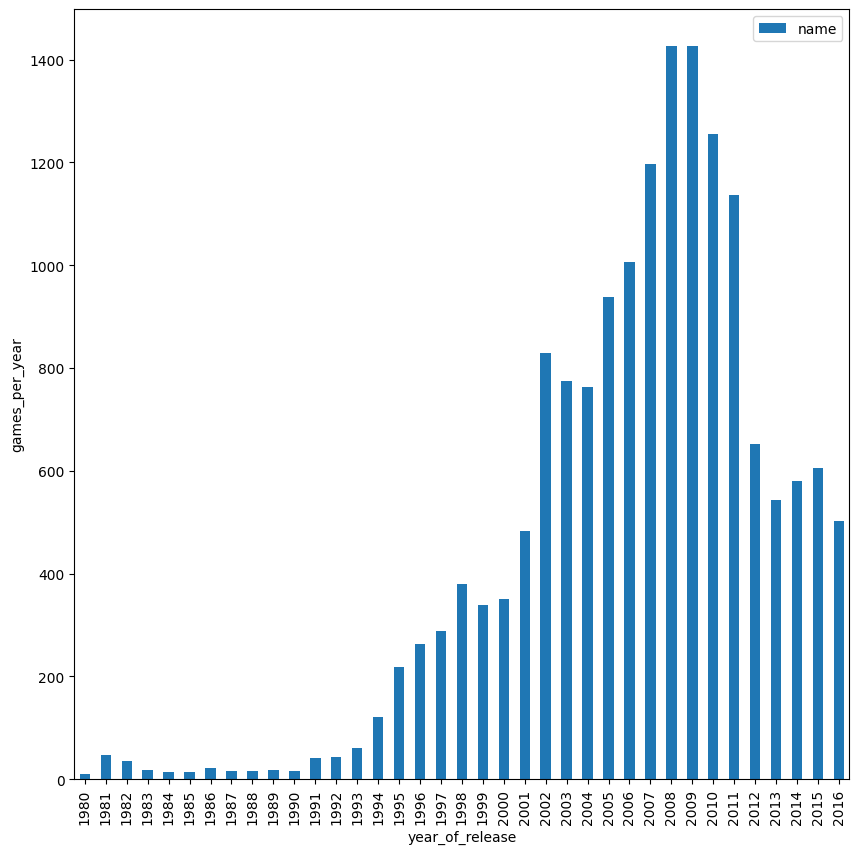

In [35]:
games_per_year.plot(kind = "bar", figsize = (10, 10), xlabel = "year_of_release", ylabel = "games_per_year") #graficamos

In [36]:
#observamos que el incremento anual de lanzamientos empieza pasando 1990 teniendo un pico entre 2008 y 2009, para el año 2010
#empieza a disminuir significativamente los lanzamientos por año, esto puede ser debido a que debido a los avances tecnologicos,
#de motores graficos y de tecnologia, los juegos cada vez fueron incorporando mas y mas cosas haciendo que los tiempos de 
#desarrollo de cada juego sea mas extenso por tanto resultando en una disminucion de lanzamientos por año, a partir del 2012
#se observa que los lanzamientos empiezan a estandarizarse en un rango

In [37]:
#antes de continuar con la proyeccion a 2017, necesitamos evaluar las ventas por plataforma

sales_per_platform = games_data.pivot_table(index = "platform", values = "global_sales", aggfunc = "sum").sort_values(by = "global_sales", ascending = False)
print(sales_per_platform)

          global_sales
platform              
PS2            1233.56
X360            961.24
PS3             931.34
Wii             891.18
DS              802.78
PS              727.58
PS4             314.14
GBA             312.88
PSP             289.53
3DS             257.81
PC              255.76
GB              254.43
XB              251.57
NES             251.05
N64             218.01
SNES            200.04
GC              196.73
XOne            159.32
2600             86.48
WiiU             82.19
PSV              53.81
SAT              33.59
GEN              28.35
DC               15.95
SCD               1.86
NG                1.44
WS                1.42
TG16              0.16
3DO               0.10
GG                0.04
PCFX              0.03


In [38]:
most_popular_platform = sales_per_platform.index[:10] #hacemos un top10 plataformas mas populares
print(most_popular_platform)

Index(['PS2', 'X360', 'PS3', 'Wii', 'DS', 'PS', 'PS4', 'GBA', 'PSP', '3DS'], dtype='object', name='platform')


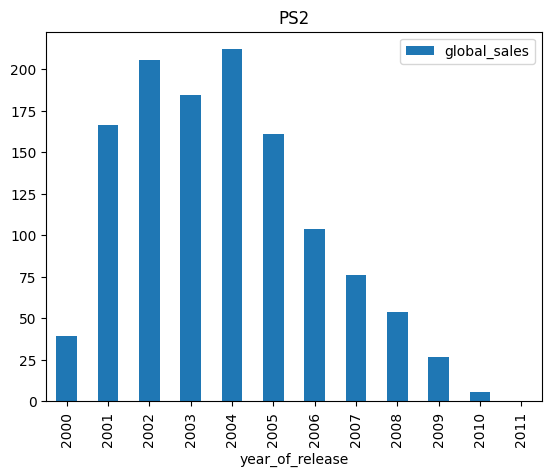

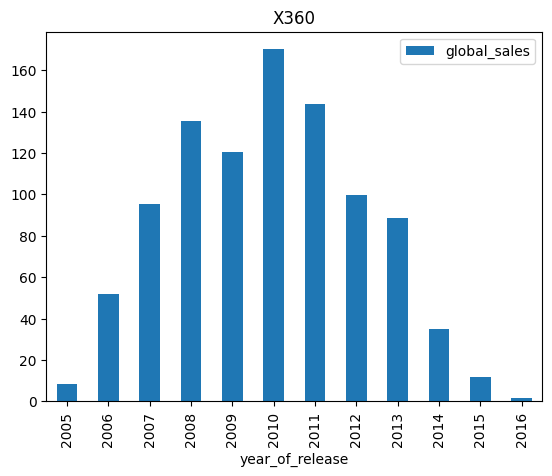

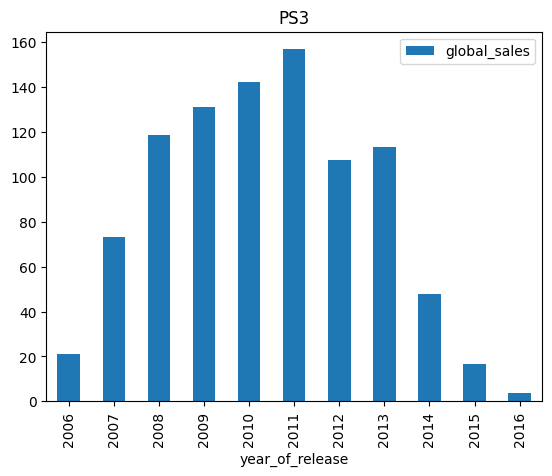

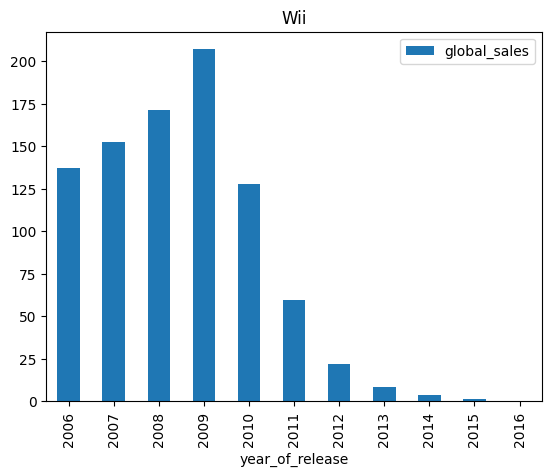

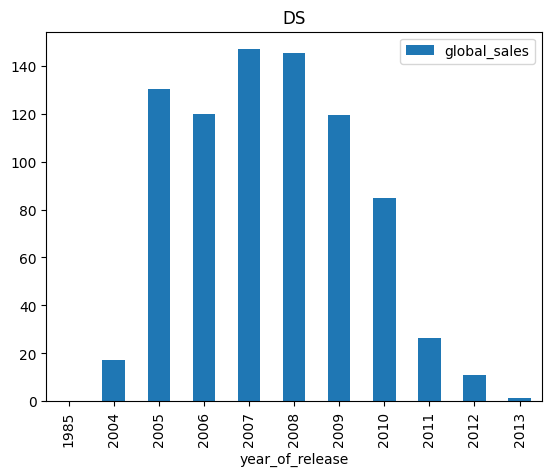

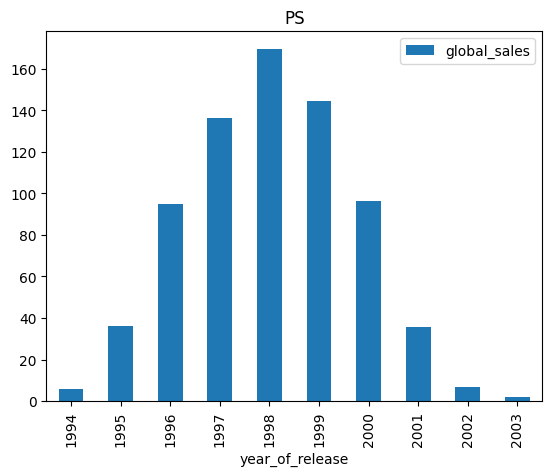

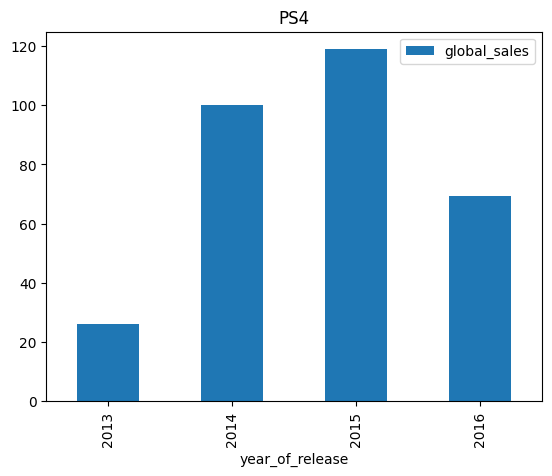

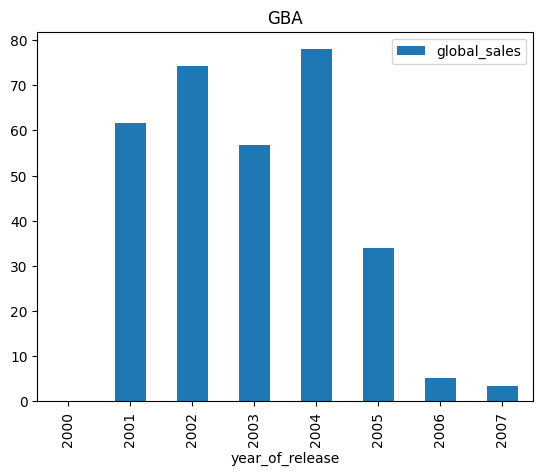

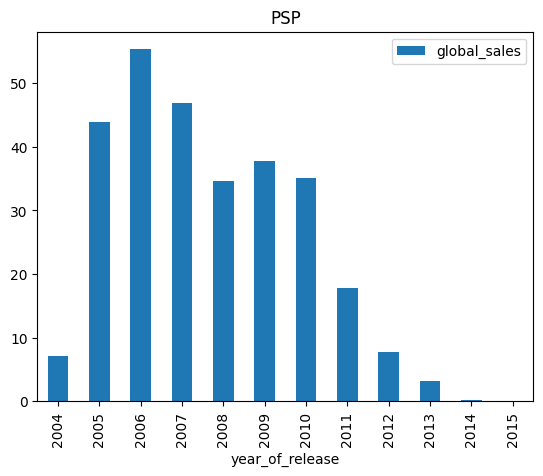

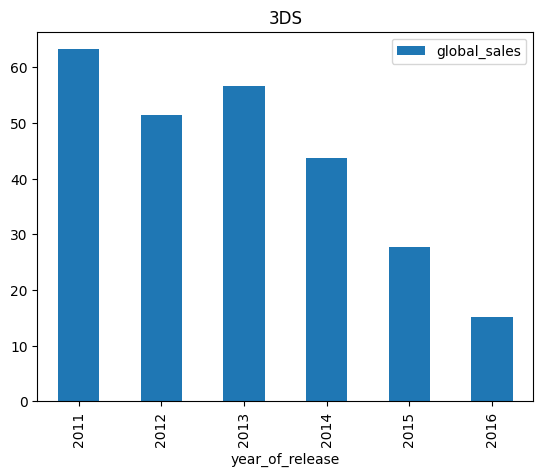

In [39]:
for platform in most_popular_platform:
    games_data[games_data["platform"] == platform].pivot_table(index = "year_of_release", values = "global_sales", aggfunc = "sum").plot(kind = "bar", title = platform)

In [40]:
#como dato, el PS2 ademas de ser la plataforma mas popular, su produccion se interrumpio en enero del 2013, a pesar de que ya
#no no se producian consolas, los lanzamientos de juegos para la PS2 continuaron hasta casi el fin de ese mismo año y es 
#considerada la consola mas vendida de la historia por sus mas de 10 años en el mercado. Extraño mi PS2.

In [41]:
#De las graficas podemos observar que las ventas por año se mantienen entre 4 a 6 años antes de que empiece a disminuir,
#esto debido a que durante ese periodo empiezan las planeaciones y anuncios de la siguiente generacion de consolas y los
#lanzamientos de titulos poco a poco se dejan de priorizar para la generacion en turno y empiezan a priorizarse para la 
#generacion siguiente.

In [42]:
#Para la proyeccion a 2017, tenemos informacion de ventas y lanzamientos de juego, con los datos obtenidos, para nuestro
#analisis tomaresmos el año 2012 ya que es el año donde se empieza a estabilizar el mercado segun la grafica global. Tambien
#tomamos en cuenta que los picos de ventas son entre 4 a 6 años antes de que empiece a decender por la generacion entrante.

In [43]:
new_games_data = games_data[games_data["year_of_release"]>= 2012].reset_index(drop = True)
new_games_data

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,global_sales
0,Grand Theft Auto V,PS3,2013,Action,7.02,9.09,0.98,3.96,97.0,8.2,M,21.05
1,Grand Theft Auto V,X360,2013,Action,9.66,5.14,0.06,1.41,97.0,8.1,M,16.27
2,Call of Duty: Black Ops 3,PS4,2015,Shooter,6.03,5.86,0.36,2.38,NaN,NaN,unknown,14.63
3,Pokemon X/Pokemon Y,3DS,2013,Role-Playing,5.28,4.19,4.35,0.78,NaN,NaN,unknown,14.60
4,Call of Duty: Black Ops II,PS3,2012,Shooter,4.99,5.73,0.65,2.42,83.0,5.3,M,13.79
...,...,...,...,...,...,...,...,...,...,...,...,...
2881,Strawberry Nauts,PSV,2016,Adventure,0.00,0.00,0.01,0.00,NaN,NaN,unknown,0.01
2882,Aiyoku no Eustia,PSV,2014,Misc,0.00,0.00,0.01,0.00,NaN,NaN,unknown,0.01
2883,Samurai Warriors: Sanada Maru,PS3,2016,Action,0.00,0.00,0.01,0.00,NaN,NaN,unknown,0.01
2884,Haitaka no Psychedelica,PSV,2016,Adventure,0.00,0.00,0.01,0.00,NaN,NaN,unknown,0.01


In [44]:
new_games_data.isnull().sum() #Comprobamos datos ausentes

name                  0
platform              0
year_of_release       0
genre                 0
na_sales              0
eu_sales              0
jp_sales              0
other_sales           0
critic_score       1574
user_score         1355
rating                0
global_sales          0
dtype: int64

In [45]:
#debido a que anteriormente trabajamos los datos ausentes, critic_score y user_score permanecen de la misma manera, optamos
#por el mismo manejo, por las mismas razones antes mencionadas, unicamente verificamos para estar seguros
new_games_data[new_games_data["critic_score"].isna()]

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,global_sales
2,Call of Duty: Black Ops 3,PS4,2015,Shooter,6.03,5.86,0.36,2.38,NaN,NaN,unknown,14.63
3,Pokemon X/Pokemon Y,3DS,2013,Role-Playing,5.28,4.19,4.35,0.78,NaN,NaN,unknown,14.60
7,Pokemon Omega Ruby/Pokemon Alpha Sapphire,3DS,2014,Role-Playing,4.35,3.49,3.10,0.74,NaN,NaN,unknown,11.68
12,Minecraft,X360,2013,Misc,5.70,2.65,0.02,0.81,NaN,NaN,unknown,9.18
16,Pokemon Black 2/Pokemon White 2,DS,2012,Role-Playing,2.79,1.72,3.14,0.41,NaN,NaN,unknown,8.06
...,...,...,...,...,...,...,...,...,...,...,...,...
2881,Strawberry Nauts,PSV,2016,Adventure,0.00,0.00,0.01,0.00,NaN,NaN,unknown,0.01
2882,Aiyoku no Eustia,PSV,2014,Misc,0.00,0.00,0.01,0.00,NaN,NaN,unknown,0.01
2883,Samurai Warriors: Sanada Maru,PS3,2016,Action,0.00,0.00,0.01,0.00,NaN,NaN,unknown,0.01
2884,Haitaka no Psychedelica,PSV,2016,Adventure,0.00,0.00,0.01,0.00,NaN,NaN,unknown,0.01


In [46]:
#Para las plataformas lideres de ventas crearemos un dataset con los datos por platafomra

In [47]:
top_platforms = new_games_data.pivot_table(index = "platform", values = "global_sales", aggfunc = "sum").sort_values(by = "global_sales", ascending = False)
print(top_platforms)

          global_sales
platform              
PS4             314.14
PS3             288.79
X360            236.54
3DS             194.61
XOne            159.32
WiiU             82.19
PC               62.65
PSV              49.18
Wii              35.37
DS               12.55
PSP              11.19


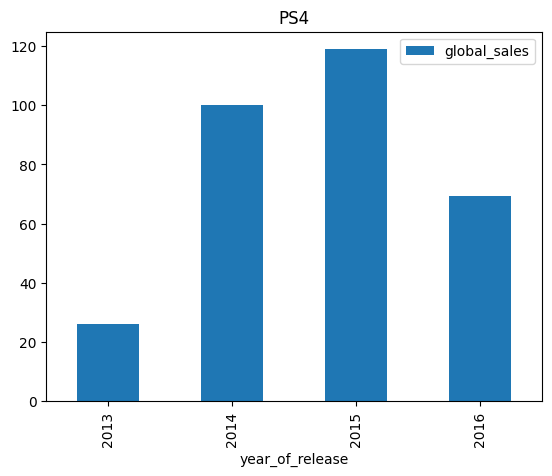

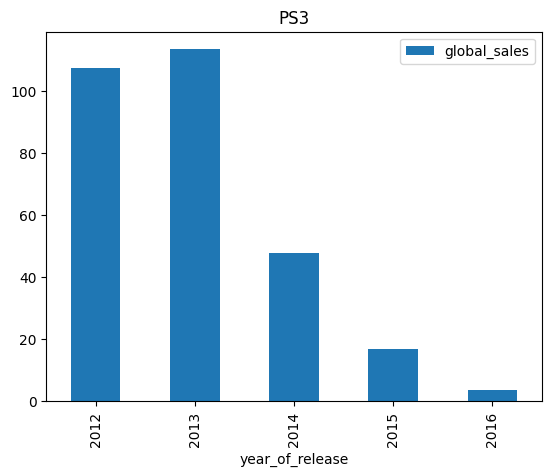

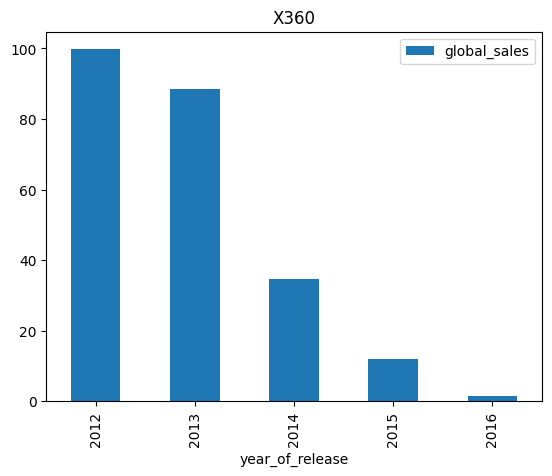

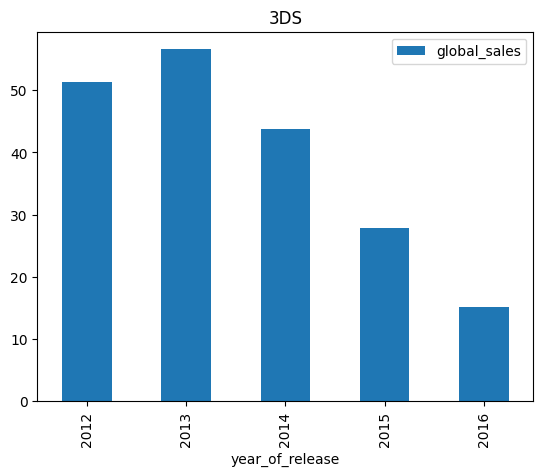

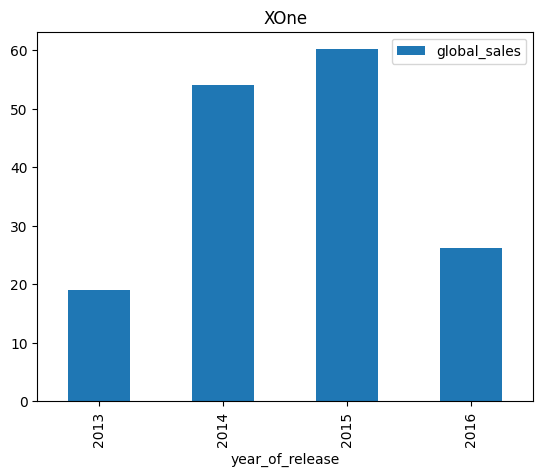

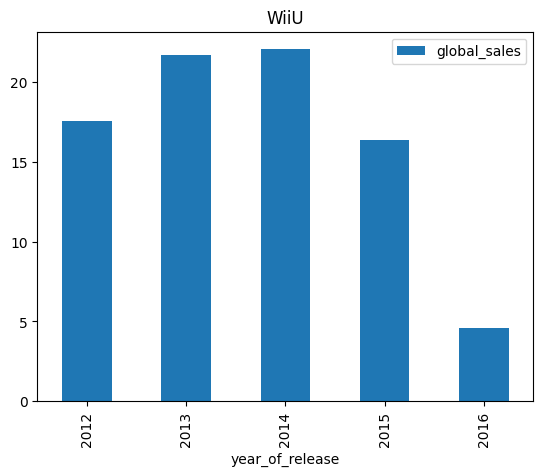

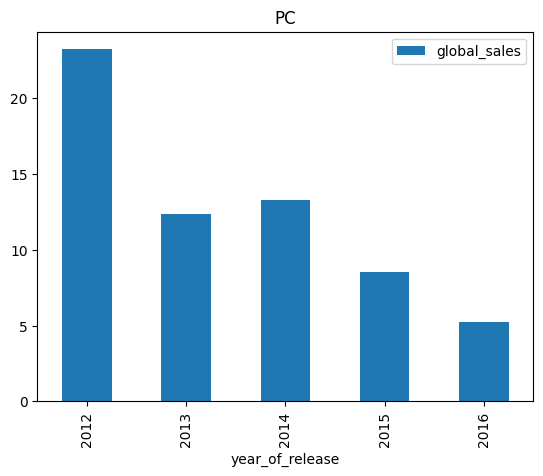

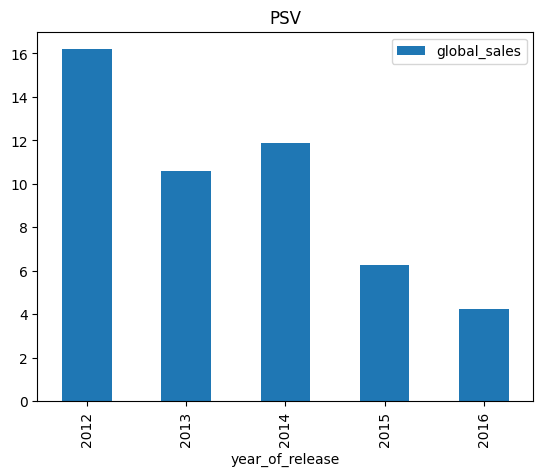

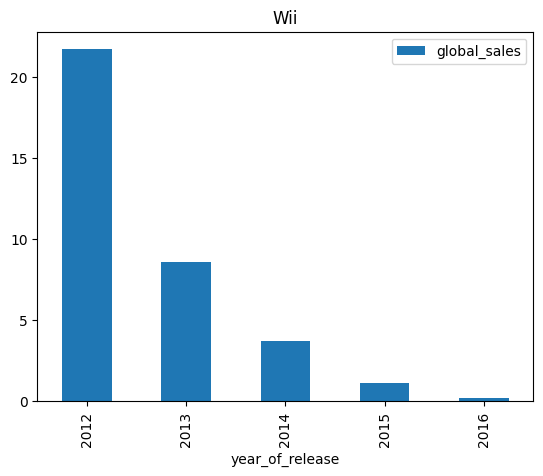

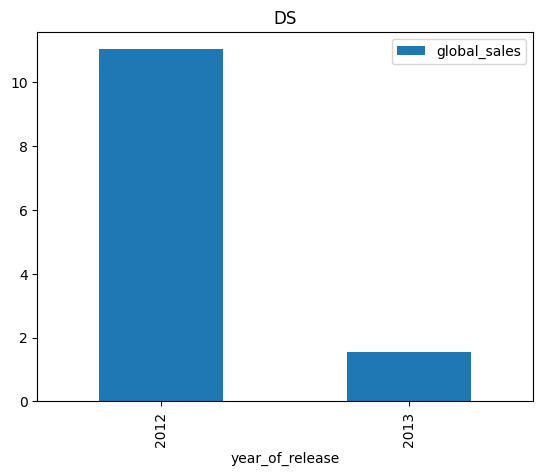

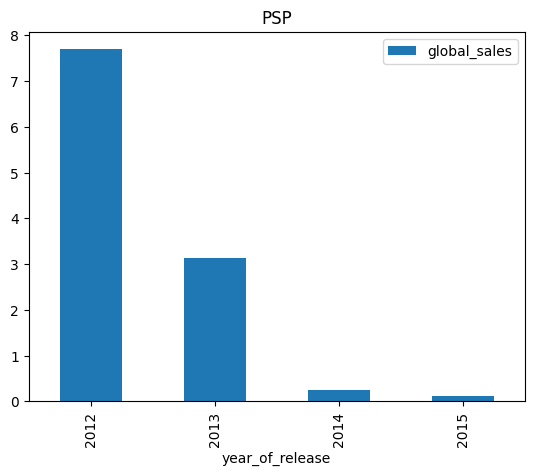

In [48]:
for platform in top_platforms.index:
    new_games_data[new_games_data["platform"] == platform].pivot_table(index = "year_of_release", values = "global_sales", aggfunc = "sum").plot(kind = "bar", title = platform)

In [49]:
#En las graficas podemos observar el mismo comportamiento descrito antes, las ventas empiezan a disminuir conforme entra la
#nueva generacion de consolas, los picos de popularidad tambien se presentan en auge en las consolas actuales por tanto
#podriamos seleccionar las plataformas lideres de la generacion actual y anterior siendo PS3, PS4, X360, XOne, 3DS, WiiU y PC
#(wii no lo consideramos debido a la aburpta disminuscion de ventas de un año a otro).

In [50]:
top_platforms = ["PS3", "PS4", "X360", "XOne", "3DS", "WiiU", "PC"] #agrupamos plataformas mas populares
top_games_data = new_games_data[new_games_data["platform"].isin(top_platforms)]
top_games_data

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,global_sales
0,Grand Theft Auto V,PS3,2013,Action,7.02,9.09,0.98,3.96,97.0,8.2,M,21.05
1,Grand Theft Auto V,X360,2013,Action,9.66,5.14,0.06,1.41,97.0,8.1,M,16.27
2,Call of Duty: Black Ops 3,PS4,2015,Shooter,6.03,5.86,0.36,2.38,NaN,NaN,unknown,14.63
3,Pokemon X/Pokemon Y,3DS,2013,Role-Playing,5.28,4.19,4.35,0.78,NaN,NaN,unknown,14.60
4,Call of Duty: Black Ops II,PS3,2012,Shooter,4.99,5.73,0.65,2.42,83.0,5.3,M,13.79
...,...,...,...,...,...,...,...,...,...,...,...,...
2873,Aikatsu Stars! My Special Appeal,3DS,2016,Action,0.00,0.00,0.01,0.00,NaN,NaN,unknown,0.01
2874,End of Nations,PC,2012,Strategy,0.01,0.00,0.00,0.00,NaN,NaN,T,0.01
2878,Dynasty Warriors: Eiketsuden,PS3,2016,Action,0.00,0.00,0.01,0.00,NaN,NaN,unknown,0.01
2879,Metal Gear Solid V: Ground Zeroes,PC,2014,Action,0.00,0.01,0.00,0.00,80.0,7.6,M,0.01


In [51]:
global_sales_per_platform = top_games_data.pivot_table(index = "platform", values = "global_sales", aggfunc = "sum").sort_values(by = "global_sales", ascending = False)
global_sales_per_platform

,global_sales
platform,
PS4,314.14
PS3,288.79
X360,236.54
3DS,194.61
XOne,159.32
WiiU,82.19
PC,62.65


Text(0.5, 1.0, 'Global sales per platform')

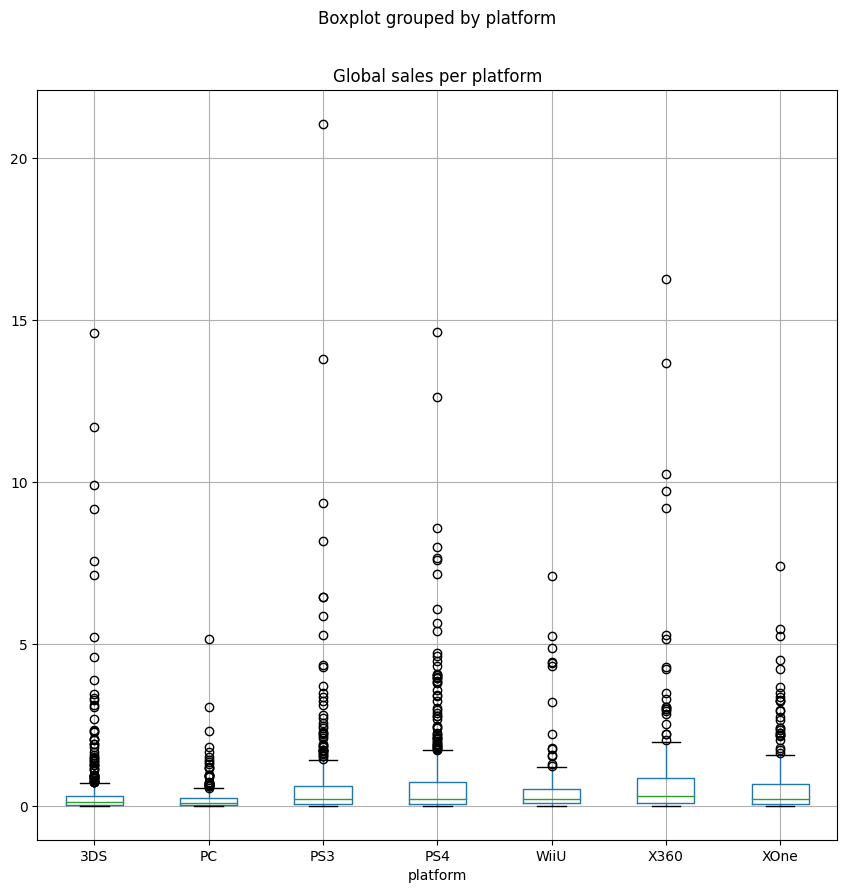

In [52]:
top_games_data.boxplot(by = "platform", column = "global_sales", figsize = (10,10)).set_title("Global sales per platform")
#se construyen los diagramas de caja para las plataformas

Text(0.5, 1.0, 'Global sales per platform')

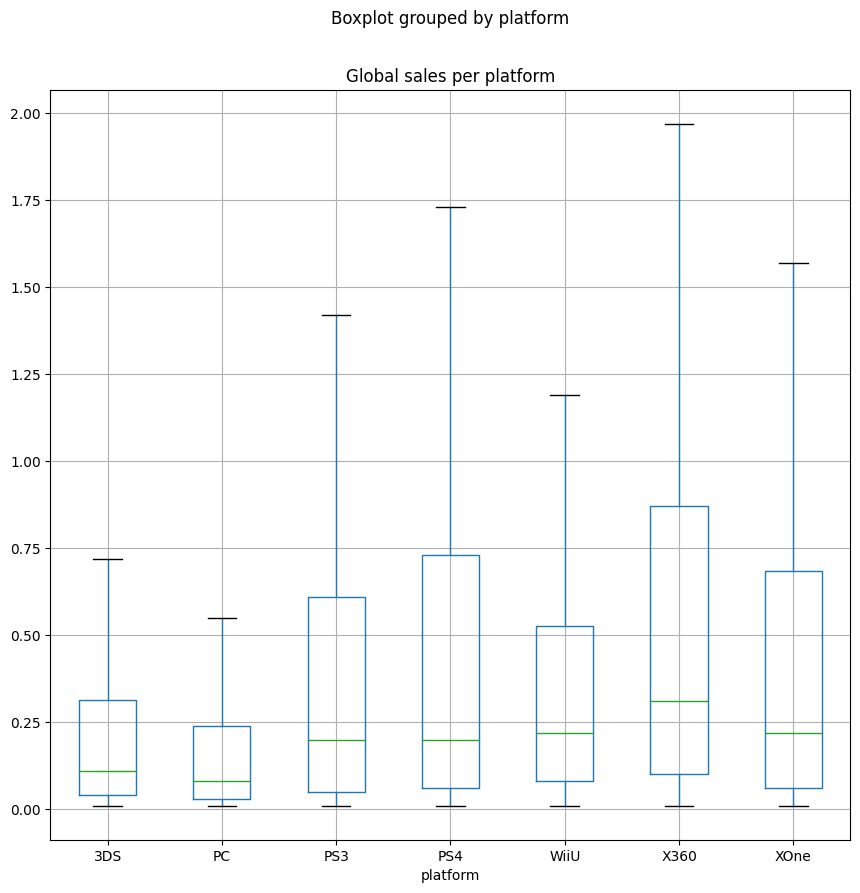

In [53]:
top_games_data.boxplot(by = "platform", column = "global_sales", figsize = (10,10), showfliers = False).set_title("Global sales per platform")
#mostramos los diagramas sin los valores atipicos

In [54]:
#de los graficos podemos observar la diferencia entre las ventas globales por plataforma, como observacion, X360 tiene un
#promedio mayor de ventas a comparacion de las demas a pesar de que no ocupa el primer puesto, esto tambien puede ser debido
#al precio de cada juego por plataforma o inclusive a los juegos exclusivos por consola

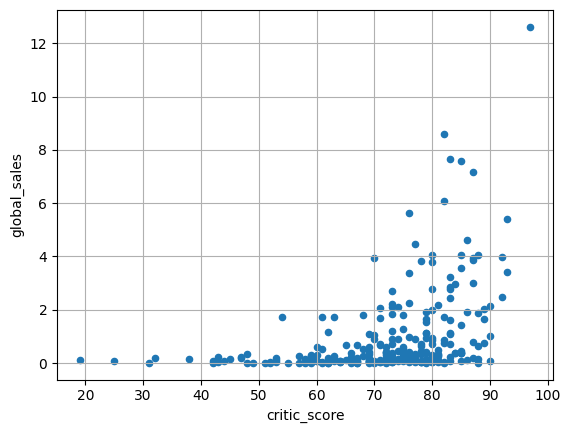

In [55]:
#vamos a analizar la relacion de critic_score/global_sales de la plataforma mas popular del momento, PS4
top_games_data[top_games_data["platform"] == "PS4"].plot.scatter(x = "critic_score", y = "global_sales").grid()

In [56]:
top_games_data[top_games_data["platform"] == "PS4"]["critic_score"].corr(top_games_data[top_games_data["platform"] == "PS4"]["global_sales"])
#coeficiente de correlacion

0.40656790206178095

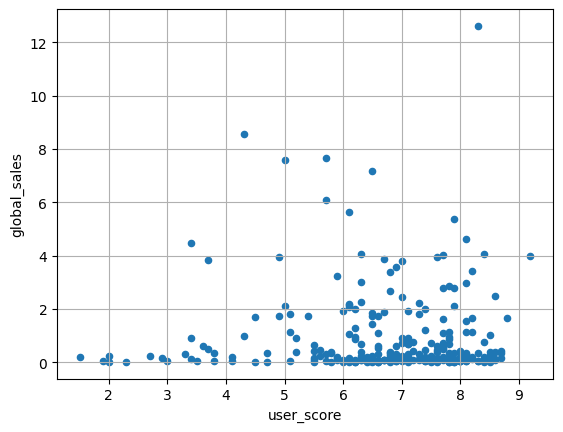

In [57]:
top_games_data[top_games_data["platform"] == "PS4"].plot.scatter(x = "user_score", y = "global_sales").grid()
#relacion user_score/global_sales

In [58]:
top_games_data[top_games_data["platform"] == "PS4"]["user_score"].corr(top_games_data[top_games_data["platform"] == "PS4"]["global_sales"])
#coeficiente de correlacion

-0.031957110204556376

In [59]:
#de los graficos anteriores podemos observar por parte de critic_score y global_sales hay una cierta relacion, se podria decir
#que la critica "especializada" influye en la venta de los juegos, y se logra apreciar en el grafico, caso contrario con
#user_score, podemos observar que hay dispersion entre los puntos y el coeficiente de correlacion es negativo pero cercano a 0,
#por tanto podriamos intuir que la relacion entre user_score y global_sales es nula, lo cual en mi opinion es positivo ya que
#para saber si un juego es bueno o malo hay que formarse un criterio propio, y la mejor forma de hacerlo es dandole una oportunidad
#a cada juego.

In [60]:
#Procedemos con el analisis del mismo juego en diferentes plataformas que son lideres en ventas globales.
top_games_data.pivot_table(index = "name", values = "global_sales", aggfunc = "sum").sort_values(by = "global_sales", ascending = False).head()

,global_sales
name,
Grand Theft Auto V,56.58
Call of Duty: Black Ops II,29.40
Call of Duty: Ghosts,27.39
Call of Duty: Black Ops 3,25.67
Minecraft,22.20


<AxesSubplot:title={'center':'GTA 5 sales'}, xlabel='platform'>

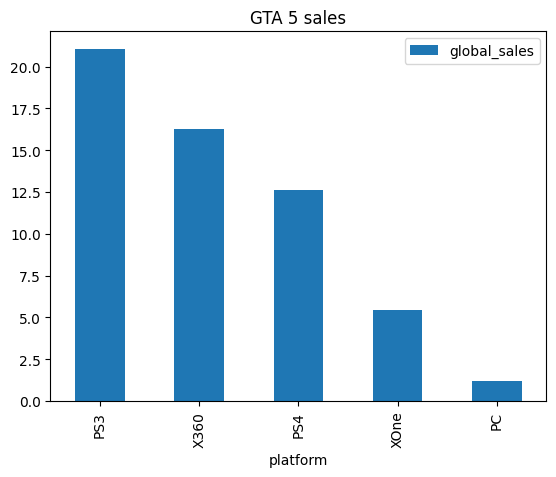

In [61]:
#el juego mas vendido multiplataforma es Grand Theft Auto V (GTA 5 (hicimos un analisis de ventas de GTA 5 antes que saliera
#GTA 6) que sorpresa), procedemos a graficar sus ventas del top 3, tenemos en segundo puesto a Call of Duty: Black Ops II (COD BO2),
#y en tercer lugar Call of Duty: Ghosts (COD: Ghosts)
top_games_data[top_games_data["name"] == "Grand Theft Auto V"].plot(kind = "bar", x = "platform", y = "global_sales", title = "GTA 5 sales")

<AxesSubplot:title={'center':'COD BO2 sales'}, xlabel='platform'>

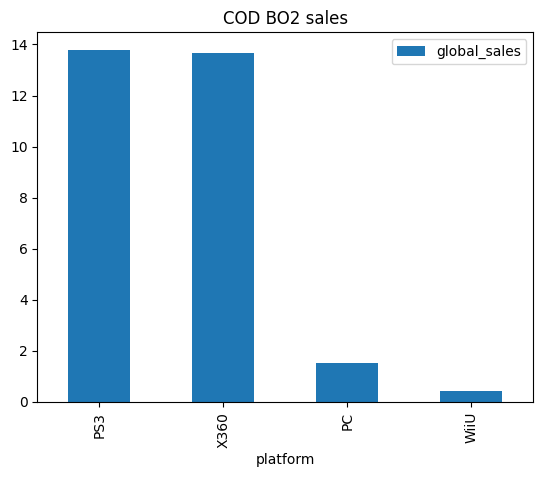

In [62]:
top_games_data[top_games_data["name"] == "Call of Duty: Black Ops II"].plot(kind = "bar", x = "platform", y = "global_sales", title = "COD BO2 sales")

<AxesSubplot:title={'center':'COD: Ghosts sales'}, xlabel='platform'>

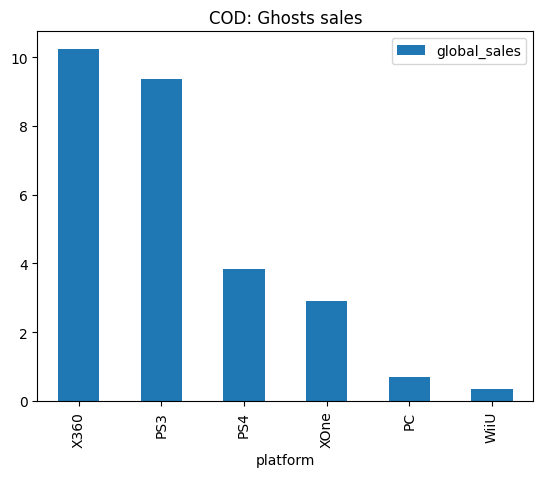

In [63]:
top_games_data[top_games_data["name"] == "Call of Duty: Ghosts"].plot(kind = "bar", x = "platform", y = "global_sales", title = "COD: Ghosts sales")

In [64]:
#De los graficos podemos verificar que el top 3 esta distribuido de ventas mayoritarias entre el X360 y el PS3, este comportamiento
#es normal ya que el auge de la generacion de consolas pasadas (PS3/X360) puede que ya haya concluido, en la generacion de consolas
#actual, el auge esta sucediendo y falta ver que juegos se posicionan como multiplataformas mas vendidos

In [65]:
#procedemos a hacer el analisis de los generos mas rentables de la industria 
sales_per_genre = top_games_data.pivot_table(index = "genre", values = "global_sales", aggfunc = "sum").sort_values(by = "global_sales", ascending = False)
print(sales_per_genre)

              global_sales
genre                     
Action              408.46
Shooter             302.39
Sports              174.23
Role-Playing        167.80
Misc                 61.97
Platform             55.80
Racing               51.28
Fighting             41.92
Simulation           34.58
Adventure            23.72
Strategy             12.02
Puzzle                4.07


<AxesSubplot:title={'center':'sales per genre'}, xlabel='genre'>

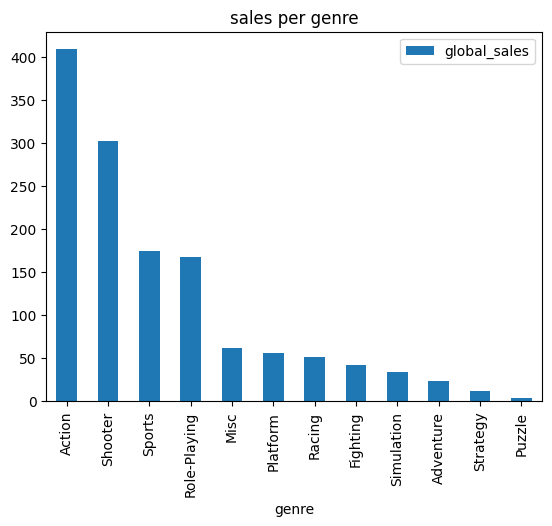

In [66]:
sales_per_genre.plot(kind = "bar", title = "sales per genre") #graficamos

In [67]:
#Podemos observar que la grafica nos hace coincidir con los multiplataformeros, GTA es principalmente del genero de accion/aventura
#asi como los COD's son shooters en primera persona, son los 2 generos mas populares en el mercado, el menos popular que observamos
#es del genero puzzle, una gran cantidad de juegos "indie" (que no son desarrollados por una mega compañia, o sea son desarrollados
#por compañias independientes/pequeñas) se desarrollan en el genero puzzle, este tipo de juegos por lo general son o gratis o  
#a un precio muy economico, tambien muchas veces son desarrollados para moviles y son de descarga gratuita.

In [68]:
#procedemos a hacer el perfil por region, iniciamos con las 5 plataformas principales para cada region

In [69]:

#ventas de NA por plataforma
top_games_data.pivot_table(index = "platform", values = "na_sales", aggfunc = "sum").sort_values(by = "na_sales", ascending = False)


,na_sales
platform,
X360,140.05
PS4,108.74
PS3,103.38
XOne,93.12
3DS,55.31
WiiU,38.10
PC,19.12


<AxesSubplot:title={'center':'NA sales'}, xlabel='platform'>

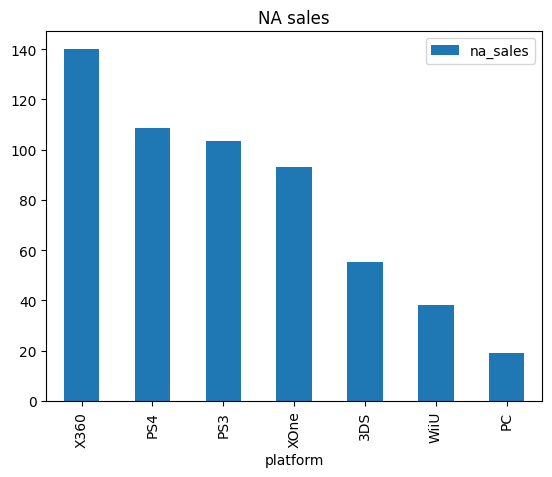

In [70]:
#graficamos
top_games_data.pivot_table(index = "platform", values = "na_sales", aggfunc = "sum").sort_values(by = "na_sales", ascending = False).plot(kind = "bar", title = "NA sales")

In [71]:

#ventas de EU por plataforma
top_games_data.pivot_table(index = "platform", values = "eu_sales", aggfunc = "sum").sort_values(by = "eu_sales", ascending = False)


,eu_sales
platform,
PS4,141.09
PS3,106.86
X360,74.52
XOne,51.59
3DS,42.64
PC,37.76
WiiU,25.13


<AxesSubplot:title={'center':'EU sales'}, xlabel='platform'>

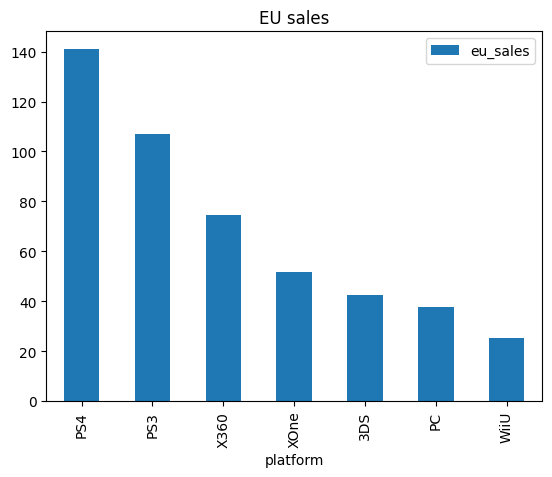

In [72]:

#graficamos
top_games_data.pivot_table(index = "platform", values = "eu_sales", aggfunc = "sum").sort_values(by = "eu_sales", ascending = False).plot(kind = "bar", title = "EU sales")


In [73]:
#ventas de JP por plataforma
top_games_data.pivot_table(index = "platform", values = "jp_sales", aggfunc = "sum").sort_values(by = "jp_sales", ascending = False)

,jp_sales
platform,
3DS,87.79
PS3,35.29
PS4,15.96
WiiU,13.01
X360,1.57
XOne,0.34
PC,0.00


<AxesSubplot:title={'center':'JP sales'}, xlabel='platform'>

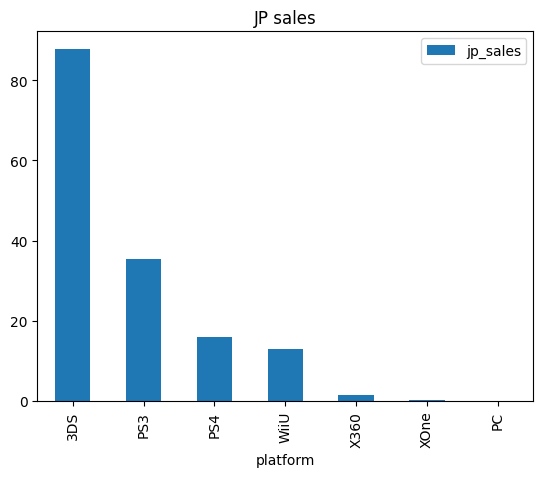

In [74]:
#graficamos
top_games_data.pivot_table(index = "platform", values = "jp_sales", aggfunc = "sum").sort_values(by = "jp_sales", ascending = False).plot(kind = "bar", title = "JP sales")


In [75]:
#del analisis podemos observar que cada region tiene su consola dominante, en NA el X360 es mas popular, en EU el PS4 y donde
#existe una gran diferencia es en JP, siendo el 3DS el mas popular por una notable diferencia.

In [76]:
#Generos por region

In [77]:
#generos populares en NA 
top_games_data.pivot_table(index = "genre", values = "na_sales", aggfunc = "sum").sort_values(by = "na_sales", ascending = False)

,na_sales
genre,
Action,167.44
Shooter,143.82
Sports,79.30
Role-Playing,58.52
Misc,28.72
Platform,23.33
Fighting,18.94
Racing,16.50
Adventure,8.29


<AxesSubplot:title={'center':'NA sales by genre'}, xlabel='genre'>

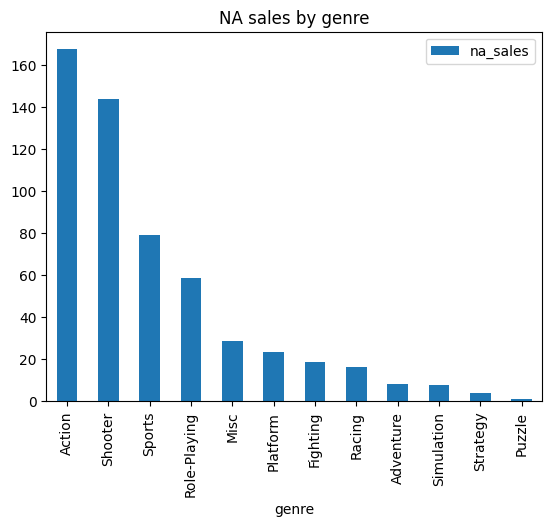

In [78]:
#graficamos
top_games_data.pivot_table(index = "genre", values = "na_sales", aggfunc = "sum").sort_values(by = "na_sales", ascending = False).plot(kind = "bar", title = "NA sales by genre")

In [79]:
#generos populares en EU
top_games_data.pivot_table(index = "genre", values = "eu_sales", aggfunc = "sum").sort_values(by = "eu_sales", ascending = False)

,eu_sales
genre,
Action,150.88
Shooter,112.64
Sports,67.00
Role-Playing,45.48
Racing,26.31
Platform,19.03
Misc,18.43
Simulation,14.41
Fighting,10.37


<AxesSubplot:title={'center':'EU sales by genre'}, xlabel='genre'>

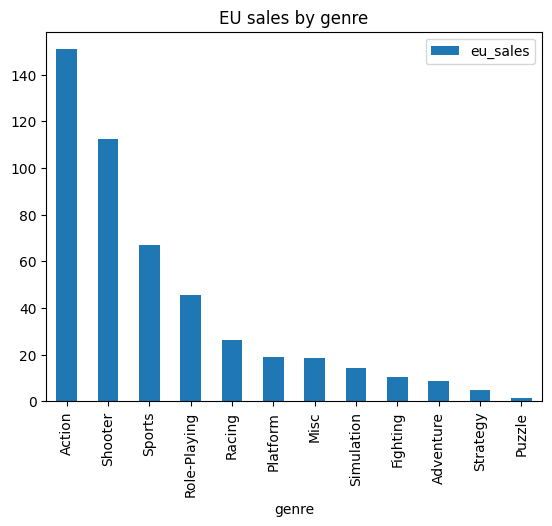

In [80]:
#graficamos
top_games_data.pivot_table(index = "genre", values = "eu_sales", aggfunc = "sum").sort_values(by = "eu_sales", ascending = False).plot(kind = "bar", title = "EU sales by genre")

In [81]:
#generos populares en JP
top_games_data.pivot_table(index = "genre", values = "jp_sales", aggfunc = "sum").sort_values(by = "jp_sales", ascending = False)

,jp_sales
genre,
Role-Playing,50.38
Action,42.04
Simulation,10.23
Shooter,9.12
Misc,9.06
Platform,8.57
Fighting,8.42
Sports,6.13
Adventure,4.28


<AxesSubplot:title={'center':'JP sales by genre'}, xlabel='genre'>

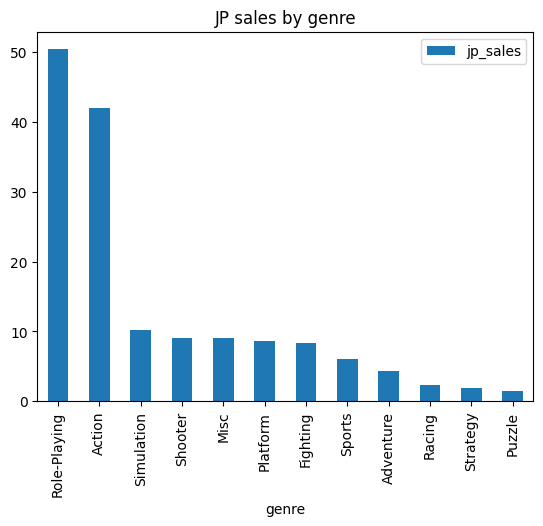

In [82]:
#graficamos
top_games_data.pivot_table(index = "genre", values = "jp_sales", aggfunc = "sum").sort_values(by = "jp_sales", ascending = False).plot(kind = "bar", title = "JP sales by genre")

In [83]:
#En cuestion de genero observamos que NA y EU mantienen la misma formula de generos populares antes establecida con action y 
#shooter en ese orden de popularidad, sin embargo, esto cambia en JP, si bien el genero action es popular no es el mas popular
#siendo role-playing el genero mas popular de la region, esto puede ser debido a las diferencias culturales por parte de la
#region.

In [84]:
#procedemos con las clasificaciones ESRB

In [85]:
#Agrupamos las ventas basandonos en las clasificaciones
sales_by_rating = top_games_data.pivot_table(index = "rating", values = ["na_sales", "eu_sales", "jp_sales"], aggfunc = "sum")
print(sales_by_rating)

         eu_sales  jp_sales  na_sales
rating                               
E          106.53     26.64    108.99
E10+        44.42      7.57     60.69
M          191.35     19.25    227.84
T           51.05     19.98     63.32
unknown     86.24     80.52     96.98


<AxesSubplot:xlabel='rating'>

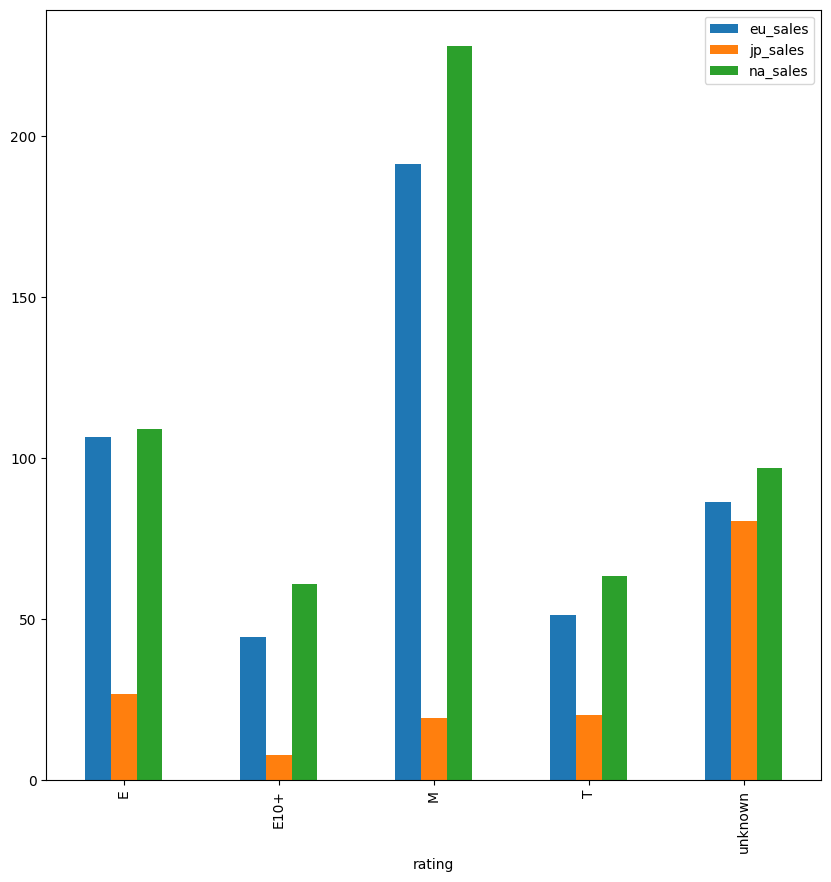

In [86]:
sales_by_rating.plot(kind = "bar", figsize = (10,10))

In [87]:
#Existen diferentes formas de clasificar los juegos, inclusive la clasificacion puede variar por region, en este caso guiandonos
#por la clasificacion ESRB que nos fue dada, podemos ver que la gran mayoria de ventas por clasificacion entran en la categoria
#M (mature) especialmente para las regiones de EU y NA, seguido por E (everyone) en las mismas regiones, tambien podemos observar
#que en la region de japon el comportamiento no es muy diferente entre generos (exceptuando E10+), es la region donde parece ser
#que la clasificacion no afecta las ventas.

In [88]:
#Pruebas de hipotesis

# 1 . Las calificaciones promedio de los usuarios para las plataformas Xbox One y PC son las mismas.
# 2 . Las calificaciones promedio de los usuarios para los géneros de Acción y Deportes son diferentes.

# alfa = 0.05

In [90]:
# hipotesis 1. Las calificaciones promedio de los usuarios para las plataformas Xbox One y PC son las mismas.
# hipotesis nula (H0): Las calificaciones promedio de los usuarios para las plataformas Xbox One y PC son iguales
# hipotesis alternativa (Ha): Las calificaciones promedio de los usuarios para las plataformas Xbox One y PC no son iguales

#basicamente es o no es

xone_users = top_games_data[top_games_data["platform"] == "XOne"]["user_score"] #clasificaciones de XOne
xone_users

21      NaN
31      7.9
34      5.4
44      6.4
53      6.2
       ... 
2854    8.2
2858    6.6
2860    NaN
2867    6.7
2871    NaN
Name: user_score, Length: 247, dtype: float64

In [92]:
xone_users = xone_users.dropna().reset_index(drop = True) #eliminamos valores NaN
xone_users #comprobamos

0      7.9
1      5.4
2      6.4
3      6.2
4      4.1
      ... 
177    6.8
178    6.0
179    8.2
180    6.6
181    6.7
Name: user_score, Length: 182, dtype: float64

In [93]:
pc_users = top_games_data[top_games_data["platform"] == "PC"]["user_score"] #clasificaciones de PC
pc_users

39      4.0
90      3.9
122     7.9
173     4.8
196     7.9
       ... 
2833    7.9
2849    NaN
2855    NaN
2874    NaN
2879    7.6
Name: user_score, Length: 250, dtype: float64

In [94]:
pc_users = pc_users.dropna().reset_index(drop = True) #eliminamos valores NaN
pc_users #comprobamos

0      4.0
1      3.9
2      7.9
3      4.8
4      7.9
      ... 
201    6.8
202    7.9
203    1.4
204    7.9
205    7.6
Name: user_score, Length: 206, dtype: float64

In [95]:
#Realizamos prueba ttest, comprobamos medias de ambas poblaciones.

In [97]:
alpha = 0.05 
results = st.ttest_ind(xone_users, pc_users, equal_var = True) #prueba de student
print("p-value: ", results.pvalue)

if results.pvalue < alpha:
    print("Rechazamos la hipotesis nula")
else:
    print("No rechazamos la hipotesis nula")

p-value:  0.5535080500643661
No rechazamos la hipotesis nula


In [98]:
results = st.ttest_ind(xone_users, pc_users, equal_var = False) #prueba de Welch
print("p-value: ", results.pvalue)

if results.pvalue < alpha:
    print("Rechazamos la hipotesis nula")
else:
    print("No rechaza
mos la hipotesis nula")

p-value:  0.5489537965134912
No rechazamos la hipotesis nula


In [99]:
#de ambas pruebas podemos observar que en ambas pruebas el p-value es de 0.5, esto debido a que ambas medias son parecidas,
#y no hay variabilidad significante entre ambas, podemos concluir que no hay diferencia estadistica significativa entre las
#clasificaciones promedio de ambas poblaciones (xbox one y pc) y por tanto no se rechaza la hipotesis nula.

In [100]:
#Hipotesis 2. 2 . Las calificaciones promedio de los usuarios para los géneros de Acción y Deportes son diferentes.
#Hipotesis nula (H0): Las calificaciones promedio de los usuarios para los géneros de Acción y Deportes son iguales.
#Hipotesis alternativa (Ha): 2 . Las calificaciones promedio de los usuarios para los géneros de Acción y Deportes son diferentes.

#nuevamente el alpha sera de 0.05

action_users = top_games_data[top_games_data["genre"] == "Action"]["user_score"] #clasificaciones del genero Action
print(action_users)

0       8.2
1       8.1
6       8.3
15      6.6
27      6.9
       ... 
2872    NaN
2873    NaN
2878    NaN
2879    7.6
2883    NaN
Name: user_score, Length: 787, dtype: float64


In [102]:
action_users = action_users.dropna().reset_index(drop = True) #eliminamos valores NaN
action_users #comprobamos

0      8.2
1      8.1
2      8.3
3      6.6
4      6.9
      ... 
464    6.0
465    8.5
466    5.1
467    6.7
468    7.6
Name: user_score, Length: 469, dtype: float64

In [103]:
sports_users = top_games_data[top_games_data["genre"] == "Sports"]["user_score"] #clasificaciones del genero Sports
print(sports_users)

14      4.3
19      5.0
26      4.3
28      5.7
52      4.5
       ... 
2781    NaN
2785    4.5
2811    1.4
2857    NaN
2858    6.6
Name: user_score, Length: 228, dtype: float64


In [104]:
sports_users = sports_users.dropna().reset_index(drop = True) #eliminamos valores NaN
sports_users #comprobamos

0      4.3
1      5.0
2      4.3
3      5.7
4      4.5
      ... 
177    6.9
178    5.5
179    4.5
180    1.4
181    6.6
Name: user_score, Length: 182, dtype: float64

In [106]:
#Realizamos prueba ttest

In [107]:
results = st.ttest_ind(action_users, sports_users)
print("p-value: ", results.pvalue)

if results.pvalue < alpha:
    print("Rechazamos la hipotesis nula")
else:
    print("No rechazamos la hipotesis nula")

p-value:  1.1824243081763574e-25
Rechazamos la hipotesis nula


In [108]:
#el valor p-value es un valor extremadamente pequeño, rechazamos la hipotesis nula, lo cual podemos concluir que existen
#diferencias significativas entre las clasificaciones promedio de usuarion entre los generos de accion y deportes, esto no
#quiere decir que un genero sea mejor que otro, solamente los usuarios tienen gustos diferentes

###### Conclusion General
Encontramos que el auge de ventas puede durar hasta 6 años, antes del declive por la entrada de la nueva generacion de consolas, basandonos en esto depende de los titulos lanzados para 2017 si el auge continua o empieza el declive puesto que se podria anunciar la siguiente generacion de consolas, tambien depende de la popularidad de titulos lanzados en el futuro ya que hay 2 tipos de riesgos, lanzar un titulo nuevo al mercado pero con el riesgo de que no sea muy atractivo para el publico como ya ha pasado con titulos que se convierten de "nicho" por lo buenos que son pero lo poco reconocidos en el mercado, o lanzar un titulo bajo una franquicia conocida (como COD o GTA) pero que el juego no cumpla con las expectativas planteadas por los juegos antecesores, tambien es recomendable hacer un estudio de ventas de titulos exclusivos y hacer una comparacion con titulos multiplataforma para encontrar si los titulos exclusivos influyen en la venta de consolas.
Las plataformas y generos mas populares pueden variar por region, especialmente en japon
Pudimos observar que la critica especializada puede inlfuir en la venta de juegos, mientras que las opiniones de usuarios pueden ser variadas y practicamente no influyen en la venta de juegos.
Las clasificaciones ESBR influyen en las ventas (exceptuando japon nuevamente) siendo la clasificacion mas vendida los titulos clasificados con M en EU y NA